# AgroÓrbit — Análise de Tendência e Projeção 2025

Notebook de tendência e projeção dos focos de queimadas usando os **3 anos completos** (2022, 2023 e 2024).

> **Atualização:** 2022 agora tem dados reais de focos (269.317 focos), obtidos do BDQueimadas
> via download direto e cruzados com as microrregiões. A regressão agora usa 3 pontos reais.

**Técnica:** Regressão linear com `scipy.stats.linregress`  
**Bioma:** Caatinga — 130 microrregiões · 9 estados  
**Mês mais crítico:** Outubro (maior volume de focos nos 3 anos)

## 1. Importações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

CAMINHO_DATA = '../data'
MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
print('bibliotecas carregadas!')

bibliotecas carregadas!


## 2. Carregando os dados

In [3]:
df = pd.read_csv(f'{CAMINHO_DATA}/dados_finais_3anos.csv')
print(f'Dataset: {df.shape}')

print('\nTotal de focos por ano (3 anos completos):')
for ano in [2022, 2023, 2024]:
    total = df[df['ano'] == ano]['focos'].sum()
    print(f'  {ano}: {total:,.0f} focos')

df.head()

Dataset: (36, 8)

Total de focos por ano (3 anos completos):
  2022: 269,317 focos
  2023: 530,448 focos
  2024: 445,913 focos


,ano,mes,mes_nome,focos,precip,umidade,temp,indice
0,2022,1,Jan,6515,116.825,66.046,26.197,0.217
1,2022,2,Fev,5095,54.476,66.464,26.274,0.325
2,2022,3,Mar,3608,195.280,66.873,26.242,0.180
3,2022,4,Abr,3769,112.823,67.255,26.055,0.228
4,2022,5,Mai,2941,120.655,67.446,26.102,0.226


## 3. Tendência anual de outubro (mês com maior volume de focos)

In [4]:
outubro = df[df['mes'] == 10][['ano','focos','precip','umidade','temp','indice']]
print('Outubro nos 3 anos:')
print(outubro.to_string(index=False))

anos_out  = outubro['ano'].values.astype(float)
focos_out = outubro['focos'].values.astype(float)

slope, intercept, r_value, p_value, std_err = stats.linregress(anos_out, focos_out)

print(f'\nRegressão linear (2022-2024) — 3 pontos:')
print(f'  Crescimento por ano: {slope:+,.0f} focos')
print(f'  R²: {r_value**2:.3f}')
print(f'  p-valor: {p_value:.4f}')

proj_2025_out = max(0, slope * 2025 + intercept)
proj_2026_out = max(0, slope * 2026 + intercept)
print(f'\nProjeção outubro 2025: {proj_2025_out:,.0f} focos')
print(f'Projeção outubro 2026: {proj_2026_out:,.0f} focos')

Outubro nos 3 anos:
 ano  focos  precip  umidade   temp  indice
2022  95845  12.045   66.402 26.403   0.412
2023 177219   6.865   64.839 26.623   0.594
2024 108577  14.675   67.074 26.645   0.557

Regressão linear (2022-2024) — 3 pontos:
  Crescimento por ano: +6,366 focos
  R²: 0.021
  p-valor: 0.9071

Projeção outubro 2025: 139,946 focos
Projeção outubro 2026: 146,312 focos


## 4. Gráfico de tendência — outubro

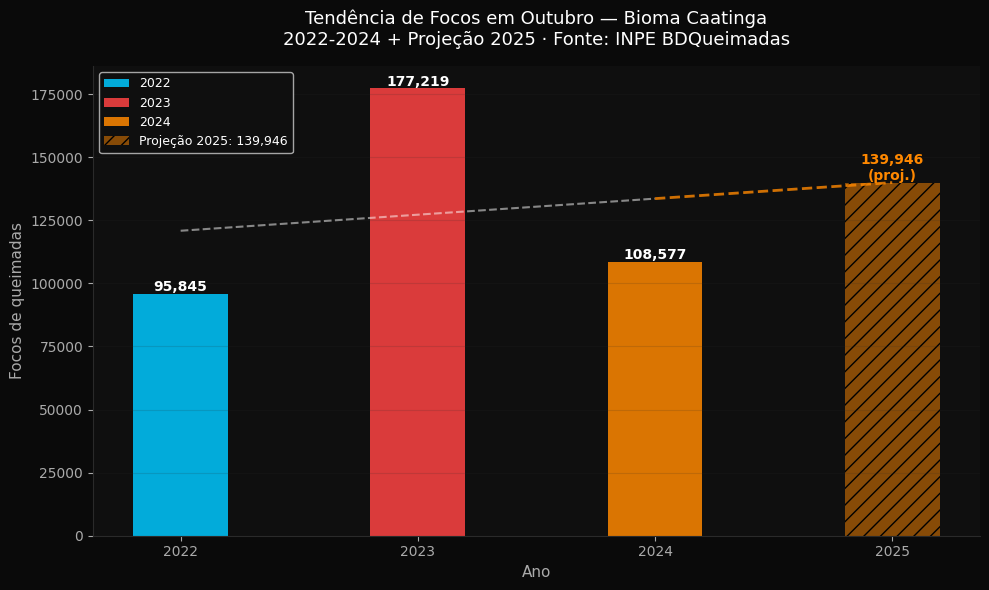

Gráfico salvo.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0f0f0f')

cores_ano = {2022:'#00c8ff', 2023:'#ff4444', 2024:'#ff8800'}
for i, (ano, foco) in enumerate(zip(anos_out.astype(int), focos_out)):
    ax.bar(ano, foco, color=cores_ano[ano], alpha=0.85, width=0.4, label=str(ano))
    ax.annotate(f'{foco:,.0f}', (ano, foco + 1000),
                ha='center', color='white', fontsize=10, fontweight='bold')

anos_linha = np.array([2022, 2023, 2024, 2025])
tendencia  = slope * anos_linha + intercept
ax.plot(anos_linha[:3], tendencia[:3], '--', color='#ffffff', linewidth=1.5, alpha=0.5)
ax.plot([2024, 2025], [tendencia[2], tendencia[3]], '--', color='#ff8800', linewidth=2, alpha=0.8)
ax.bar([2025], [proj_2025_out], color='#ff8800', alpha=0.5, width=0.4,
       label=f'Projeção 2025: {proj_2025_out:,.0f}', hatch='//')
ax.annotate(f'{proj_2025_out:,.0f}\n(proj.)', (2025, proj_2025_out + 1000),
            ha='center', color='#ff8800', fontsize=10, fontweight='bold')

ax.set_xlabel('Ano', color='#aaa', fontsize=11)
ax.set_ylabel('Focos de queimadas', color='#aaa', fontsize=11)
ax.set_title('Tendência de Focos em Outubro — Bioma Caatinga\n2022-2024 + Projeção 2025 · Fonte: INPE BDQueimadas',
             color='white', fontsize=13, pad=15)
ax.tick_params(colors='#aaa')
ax.spines['bottom'].set_color('#2a2a2a')
ax.spines['left'].set_color('#2a2a2a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, color='#2a2a2a')
ax.legend(facecolor='#0f0f0f', labelcolor='white', fontsize=9)
ax.set_xticks([2022, 2023, 2024, 2025])

plt.tight_layout()
plt.savefig(f'{CAMINHO_DATA}/grafico_tendencia_setembro.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Gráfico salvo.')

## 5. Projeção mensal completa — todos os meses

In [6]:
projecoes = []

print('PROJEÇÃO 2025 — TODOS OS MESES (baseado em 2022, 2023 e 2024)')
print('=' * 70)
print(f'{"Mês":<8} {"2022":>8} {"2023":>10} {"2024":>10} {"2025 (proj)":>12} {"Tendência":>12}')
print('-' * 70)

for mes in range(1, 13):
    dados_mes = df[df['mes'] == mes]
    anos_m  = dados_mes['ano'].values.astype(float)
    focos_m = dados_mes['focos'].values.astype(float)

    slope_m, intercept_m, _, _, _ = stats.linregress(anos_m, focos_m)
    proj = max(0, slope_m * 2025 + intercept_m)

    tendencia_txt = '↑ crescendo' if slope_m > 1000 else '↓ reduzindo' if slope_m < -1000 else '→ estável'
    projecoes.append({'mes': mes, 'nome': MESES[mes-1], 'proj_2025': proj, 'slope': slope_m})

    f22 = dados_mes[dados_mes['ano']==2022]['focos'].values[0]
    f23 = dados_mes[dados_mes['ano']==2023]['focos'].values[0]
    f24 = dados_mes[dados_mes['ano']==2024]['focos'].values[0]
    print(f'{MESES[mes-1]:<8} {f22:>8,.0f} {f23:>10,.0f} {f24:>10,.0f} {proj:>12,.0f} {tendencia_txt:>12}')

total_proj = sum(p['proj_2025'] for p in projecoes)
print('-' * 70)
print(f'{"TOTAL":<8} {"":>8} {"":>10} {"":>10} {total_proj:>12,.0f}')

PROJEÇÃO 2025 — TODOS OS MESES (baseado em 2022, 2023 e 2024)
Mês          2022       2023       2024  2025 (proj)    Tendência
----------------------------------------------------------------------
Jan         6,515     11,252     23,018       30,098  ↑ crescendo
Fev         5,095      8,717      7,399        9,374  ↑ crescendo
Mar         3,608      5,690      7,403        9,362  ↑ crescendo
Abr         3,769      5,726      4,040        4,783    → estável
Mai         2,941     10,890      8,013       12,353  ↑ crescendo
Jun         4,118     13,382     15,287       22,098  ↑ crescendo
Jul         4,196     24,504     19,481       31,345  ↑ crescendo
Ago        14,248     32,954     41,240       56,473  ↑ crescendo
Set        51,649    106,635     86,237      116,095  ↑ crescendo
Out        95,845    177,219    108,577      139,946  ↑ crescendo
Nov        40,319     81,410     63,486       84,905  ↑ crescendo
Dez        37,014     52,069     61,732       74,990  ↑ crescendo
---------

## 6. Gráfico comparativo mensal — 3 anos + projeção 2025

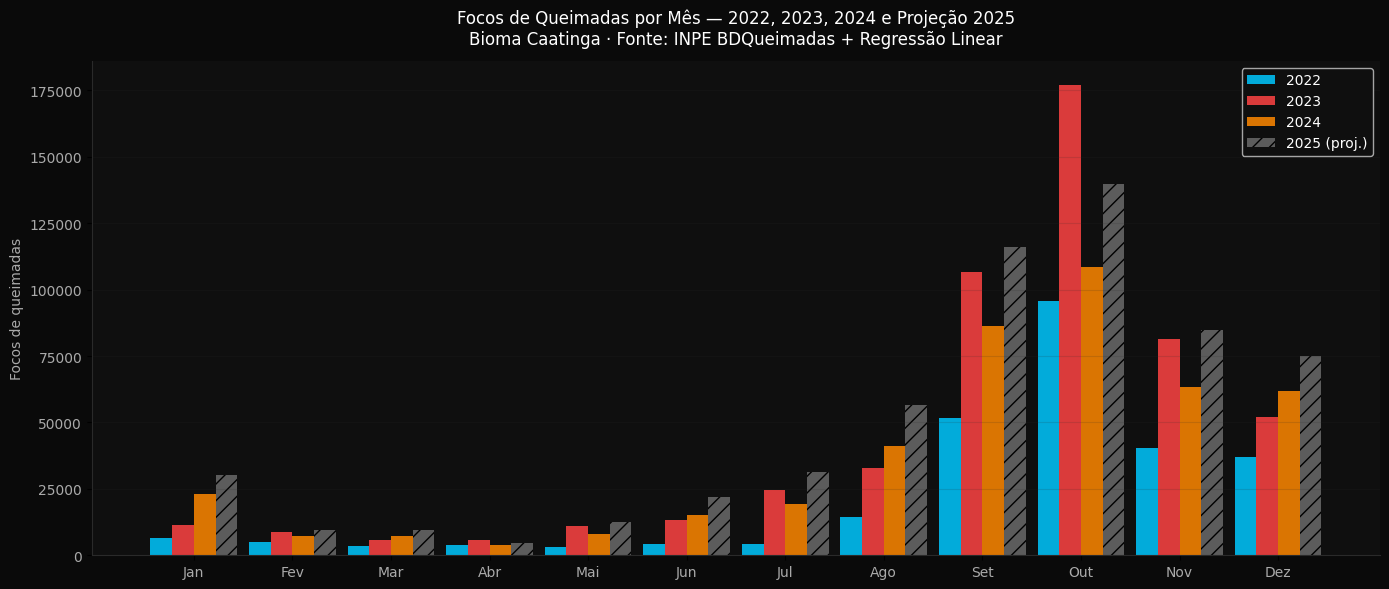

Gráfico gerado!


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0f0f0f')

x = np.arange(12)
w = 0.22

f22 = [df[(df['mes']==m) & (df['ano']==2022)]['focos'].values[0] for m in range(1,13)]
f23 = [df[(df['mes']==m) & (df['ano']==2023)]['focos'].values[0] for m in range(1,13)]
f24 = [df[(df['mes']==m) & (df['ano']==2024)]['focos'].values[0] for m in range(1,13)]
f25 = [p['proj_2025'] for p in projecoes]

ax.bar(x - 1.5*w, f22, w, label='2022', color='#00c8ff', alpha=0.85)
ax.bar(x - 0.5*w, f23, w, label='2023', color='#ff4444', alpha=0.85)
ax.bar(x + 0.5*w, f24, w, label='2024', color='#ff8800', alpha=0.85)
ax.bar(x + 1.5*w, f25, w, label='2025 (proj.)', color='#aaaaaa', alpha=0.5, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(MESES, color='#aaa')
ax.set_ylabel('Focos de queimadas', color='#aaa')
ax.tick_params(axis='y', labelcolor='#aaa')
ax.spines['bottom'].set_color('#2a2a2a')
ax.spines['left'].set_color('#2a2a2a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, color='#2a2a2a')
ax.legend(facecolor='#0f0f0f', labelcolor='white')
ax.set_title('Focos de Queimadas por Mês — 2022, 2023, 2024 e Projeção 2025\nBioma Caatinga · Fonte: INPE BDQueimadas + Regressão Linear',
             color='white', fontsize=12, pad=12)
fig.tight_layout()
plt.show()
print('Gráfico gerado!')

## 7. Conclusões

In [8]:
print('CONCLUSÕES DA ANÁLISE DE TENDÊNCIA (3 ANOS COMPLETOS)')
print('=' * 58)

out_2022 = df[(df['mes']==10) & (df['ano']==2022)]['focos'].values[0]
out_2023 = df[(df['mes']==10) & (df['ano']==2023)]['focos'].values[0]
out_2024 = df[(df['mes']==10) & (df['ano']==2024)]['focos'].values[0]

print(f'Outubro 2022: {out_2022:,} focos')
print(f'Outubro 2023: {out_2023:,} focos')
print(f'Outubro 2024: {out_2024:,} focos')
print(f'Projeção Out 2025: {proj_2025_out:,.0f} focos')
print()
print('Meses com tendência de crescimento:')
for p in projecoes:
    if p['slope'] > 1000:
        print(f'  {p["nome"]}: +{p["slope"]:,.0f} focos/ano')
print()
print('Observações:')
print('  - 2022 agora tem dados reais de focos (INPE BDQueimadas direto)')
print('  - Regressão com 3 pontos reais — mais robusta que a versão anterior')
print('  - Outubro é o mês mais crítico da Caatinga (pico de focos nos 3 anos)')
print('  - Setembro tem o maior índice de risco médio agregado')

CONCLUSÕES DA ANÁLISE DE TENDÊNCIA (3 ANOS COMPLETOS)
Outubro 2022: 95,845 focos
Outubro 2023: 177,219 focos
Outubro 2024: 108,577 focos
Projeção Out 2025: 139,946 focos

Meses com tendência de crescimento:
  Jan: +8,252 focos/ano
  Fev: +1,152 focos/ano
  Mar: +1,898 focos/ano
  Mai: +2,536 focos/ano
  Jun: +5,584 focos/ano
  Jul: +7,642 focos/ano
  Ago: +13,496 focos/ano
  Set: +17,294 focos/ano
  Out: +6,366 focos/ano
  Nov: +11,584 focos/ano
  Dez: +12,359 focos/ano

Observações:
  - 2022 agora tem dados reais de focos (INPE BDQueimadas direto)
  - Regressão com 3 pontos reais — mais robusta que a versão anterior
  - Outubro é o mês mais crítico da Caatinga (pico de focos nos 3 anos)
  - Setembro tem o maior índice de risco médio agregado
